### Plotting the photon and neutrino evolution following the BBN-simple paper


For more info on what are the formulae used and what was the process of this, refer to the research diary

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import special as sps

In [87]:
# Defining them constants 

pi = np.pi

def exp(x):
    return np.exp(x)


## Masses ##
me = 0.510998 # Mass of electron in [MeV/c^2]


## General Physical Units ##
G = 6.67e-45 # Gravitational Constant [MeV^-2] 
c = 2.99e10 # Speed of Light [cm/s]
kB = 8.617e-11 # Boltzmann Constant [MeV/Kelvin]
hbar = 6.582e-22 # Reduced Planck constant h/2pi [MeV s]
NA = 6.022e23 # Avogadro's number [# molecules/mole]


def MeVtoK(T):
    'Converts T in MeV to T9'
    eV = 1/(8.619e-5) # 1 eV/kB to Kelvin
    MeV = eV*1e6 # Converting MeV to eV/kB
    K = MeV # Converting to Kelvin
    return K*T

In [3]:
# Defining the gaussian-laguerre quadrature integrator 

def gl_integrator(func):

    n = 64 
    roots, weights = sps.roots_laguerre(n)

    integrand = func(roots) * exp(roots) 

    integral = np.dot(integrand, weights)

    return integral


In [ ]:
# Defining the functions that return the energy densities and pressure for different components of the early universe

def photon(T): 

    '''
    Returns the photon energy density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # energy/mass density
    rho_gamma = (pi**2)/15 * T**4 

    # pressure 
    P_gamma = (1/3) * rho_gamma

    # drho_gamma/dT 
    drhog_dT = (4/T) * rho_gamma

    return rho_gamma, P_gamma, drhog_dT


def electron_positron(T): 
    
    '''
    Returns the electrons/positron energy/mass density, pressure 
    and the derivative of the energy density with 
    respect to temperature (evaluated at that temperature)
    at a given temperature (in MeV)
    
    '''

    # Defining the mass/energy density function's integrand

    def rho_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = (x**2 * dist) / (exp(dist) + 1)
        return integrand

    # Integrating the integrand and multiplying with the constants 
    rho_e = (2 / pi**2) * T**4 * gl_integrator(rho_e_integrand)

    

    # Defining the pressure function's integrand

    def P_e_integrand(x):

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand = x**4 / (dist * (exp(dist) + 1))
        return integrand 
    
    # Integrating the integrand and multiplying with the constants 
    P_e = (2 / (3 * pi**2)) * T**4 * gl_integrator(P_e_integrand)



    # Defining the drho/dT function's integrand

    def drho_dT_integrand(x): 

        y = me / T
        dist = np.sqrt(x**2 + y**2)

        integrand =  (x**2 * dist**2) / (exp(dist) + 1) * exp(dist) / (exp(dist) + 1)   # wrote in split format to prevent overflow issue
        return integrand 

    # Integrating the integrand and multiplying with the constants 
    drhoe_dT = (2 / pi**2) * T**3 * gl_integrator(drho_dT_integrand)

    return rho_e, P_e, drhoe_dT



def neutrino(Tnu):
    '''
    Returns the energy/mass density and pressure for the 
    neutrinos at a given temperature (in MeV)
    
    ''' 

    Neff = 3.046

    # energy density
    rhoneutrino =7/8*pi**2/15 *Neff* Tnu**4

    # pressure
    Pneutrino = rhoneutrino/3

    return rhoneutrino, Pneutrino


$$ \frac{d T}{d t} = - 3 H (\rho + P) \left( \frac{d \rho}{d T} \right)^{-1} $$

$$ \Rightarrow \frac{d t}{d T} = - \frac{1}{3 H (\rho + P)}  \left( \frac{d \rho}{d T} \right) $$

$$ \frac{d T_\nu}{d T} = \frac{T_\nu}{3 (\rho + P)} \frac{d \rho}{d T} $$

In [102]:
# Obtaining the time as a function of the temperature 

'''
We are taking this approach, where we find the age of the universe as a function of temperature instead of 
finding the temperature as the age of universe, because all our previously defined quantities are a direct function 
of the temperature (not time). 

So it would be better to take temperature as the independent quantity instead of time, and instead 
find the age of the universe as a function of time. 

Additionally we also find the neutrino temperature as a function of the photon temperature. Together we can calculate 
the relationship between the temperatures with time. 

'''


def T_dependence(T, state): 

    t, Tnu = state

    rhoe = electron_positron(T)[0]
    rhonu = neutrino(Tnu)[0]
    rhog = photon(T)[0]

    Pe = electron_positron(T)[1]
    Pnu = neutrino(Tnu)[1]
    Pg = photon(T)[1]

    drhoe_dT = electron_positron(T)[2]
    drhog_dT = photon(T)[2]
    
    H = np.sqrt(rhoe + rhonu + rhog) * np.sqrt(8*pi*G/3)/hbar

    rho_rad = rhog + rhoe
    P_rad = Pg + Pe
    drho_dT = drhoe_dT + drhog_dT

    # rho_rad = rhog + rhoe + rhonu
    # P_rad = Pg + Pe + Pnu
    # drho_dT = drhoe_dT + drhog_dT + 4*rhonu/T


    dt_dT = - (3 * H * (rho_rad + P_rad))**(-1) * drho_dT 

    dTnu_dT = Tnu / (3 * (rho_rad + P_rad)) * drho_dT

    return [dt_dT, dTnu_dT]

In [103]:
# Using the solve_ivp functionality to obtain the solutions for the DE 

Ti = 1e1
Tf = 1e-3
n =  1024
T = np.geomspace(Ti,Tf,n)

T_dependence_solution = sp.integrate.solve_ivp(fun = T_dependence, t_span = T[[0,-1]], y0 = [0, Ti], t_eval = T)
t = t_fun.y[0]
Tnu = t_fun.y[1]

(0.1, np.float64(4170774.61869408))

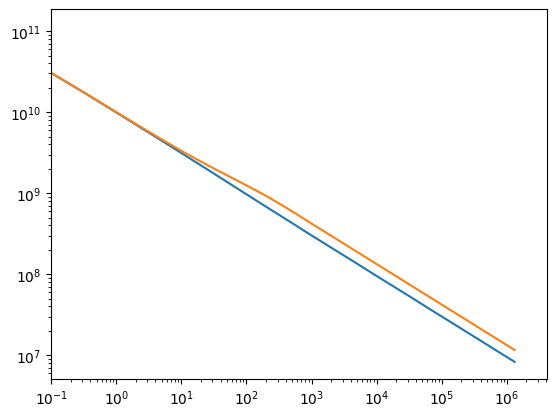

In [100]:
plt.loglog(t, MeVtoK(Tnu))
plt.loglog(t, MeVtoK(T))
plt.xlim(0.1, )

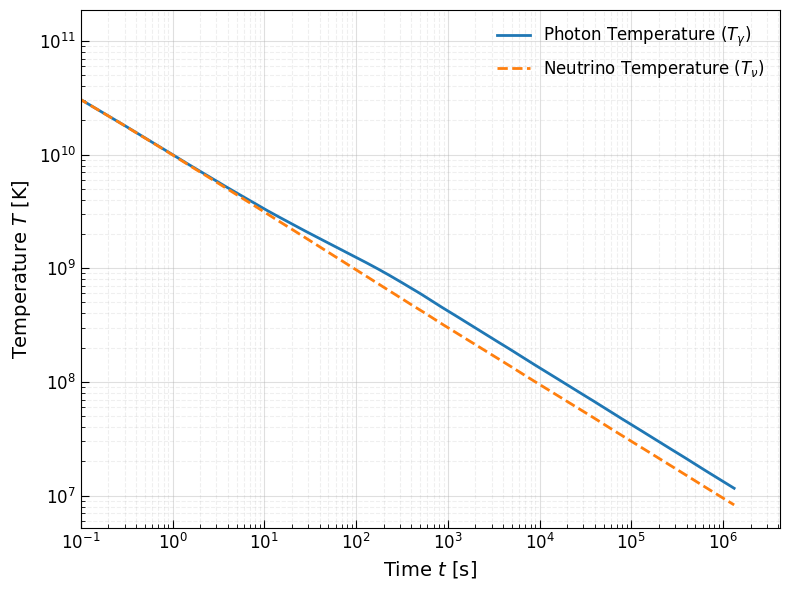

In [99]:
# Plotting the evolution of photon and neutrino temperatures

# Create a figure with a standard scientific aspect ratio
plt.figure(figsize=(8, 6))

# Plot the temperatures
plt.loglog(t, MeVtoK(T), label=r'Photon Temperature ($T_\gamma$)', linewidth=2)
plt.loglog(t, MeVtoK(Tnu), label=r'Neutrino Temperature ($T_\nu$)', linewidth=2, linestyle='--')

# Axis limits and labels
plt.xlim(left=0.1) # Keeping your lower limit constraint
plt.xlabel(r'Time $t$ [s]', fontsize=14)
plt.ylabel(r'Temperature $T$ [K]', fontsize=14)

# Tick parameters for paper-quality
plt.tick_params(axis='both', which='major', labelsize=12, length=6, direction='in')
plt.tick_params(axis='both', which='minor', length=3, direction='in')

# Add grid lines for easier reading on a log-log plot
plt.grid(True, which="major", ls="-", alpha=0.4)
plt.grid(True, which="minor", ls="--", alpha=0.2)

# Legend without an intrusive frame
plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.show()
